In [5]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('order_items.csv', 'order_items'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments')  # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Komal@959',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/KOMAL CHANDAK/OneDrive/Desktop/E-Commerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector


db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Komal@959',
    database='ecommerce'
)
cursor = db.cursor()

# List all unique cities where customers are located.

In [48]:
query = """ select distinct(customer_city) from customers"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data)
df.head(10)

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
5,jaragua do sul
6,timoteo
7,curitiba
8,belo horizonte
9,montes claros


# Count the number of orders placed in 2017.

In [8]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017"""
cursor.execute(query)
data = cursor.fetchall()
"total orders placed in 2017 are", data[0][0]

('total orders placed in 2017 are', 45101)

# Find the total sales per category.

In [18]:
query = """ select products.product_category, round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by product_category
"""

cursor.execute(query)

data = cursor.fetchall()

df = pd.DataFrame(data, columns = ["prodcut_category", "Total_sales"])
df

,prodcut_category,Total_sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


# Calculate the percentage of orders that were paid in installments

In [28]:
query = """ select (sum(case when payment_installments >= 1 then 1 else 0 end))/count(*)*100 from payments
"""

cursor.execute(query)

data = cursor.fetchall()

"the percentage of orders that were paid in installments", data[0][0]

('the percentage of orders that were paid in installments', Decimal('99.9981'))

# Count the number of customers from each state

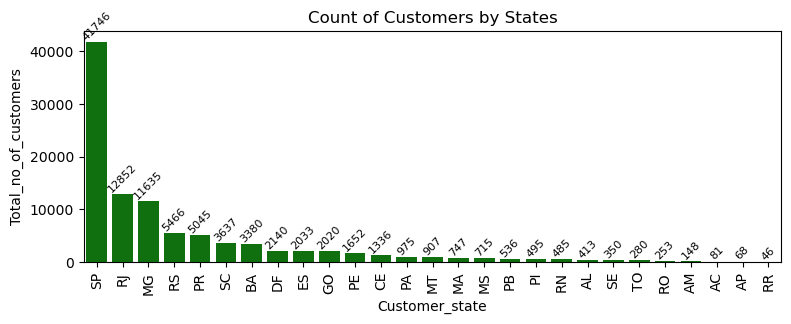

In [77]:
query = """ select customer_state, count(*) from customers group by customer_state"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["Customer_state", "Total_no_of_customers"])
df = df.sort_values(by = "Total_no_of_customers", ascending= False)
plt.figure(figsize = (9,3))
ax = sns.barplot(x = df["Customer_state"], y = df["Total_no_of_customers"], data = df, color = "green")
plt.xticks(rotation = 90)
ax.bar_label(ax.containers[0], fontsize = 8, rotation = 45)
plt.title("Count of Customers by States")
plt.show()

# Calculate the number of orders per month in 2018.

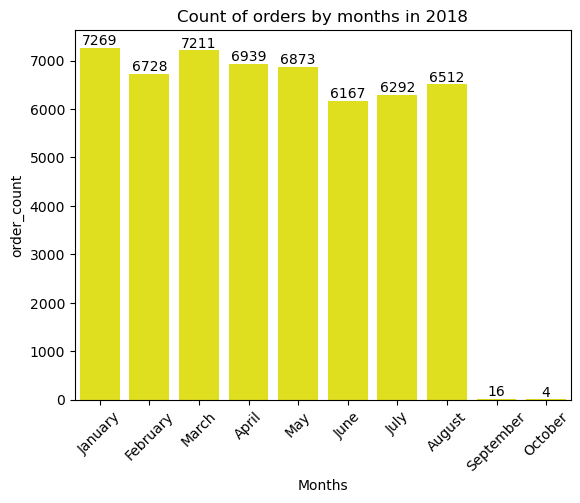

In [78]:
query = """ select monthname(order_purchase_timestamp) Months, count(order_id) order_count from orders where year(order_purchase_timestamp) = 2018 group by Months """
cursor.execute(query)
data = cursor.fetchall()
df  = pd.DataFrame(data, columns = ["Months", "order_count"])
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October"]
ax = sns.barplot(x = df["Months"], y = df["order_count"],data = df, order=o, color = "yellow")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of orders by months in 2018")
plt.show()

# Find the average number of products per order, grouped by customer city.

In [87]:
query = """ with count_per_order as (select orders.order_id, orders.customer_id, count(order_items.order_id) as Totalorder 
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.Totalorder),2) as Avg_count_of_order
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by Avg_count_of_order desc """
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["Customer_city", "Avg_count_of_order"])
df.head(5)

,Customer_city,Avg_count_of_order
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00


# Calculate the percentage of total revenue contributed by each product category.

In [107]:
query = """ select upper(products.product_category) category,round((sum(payments.payment_value)/(select sum(payment_value)from payments))*100, 2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by product_category 
order by sales_percentage desc"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["product_category", "Sales_percentage_distribution"])
df.head(20)

,product_category,Sales_percentage_distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93
5,SPORT LEISURE,8.70
6,HOUSEWARES,6.84
7,AUTOMOTIVE,5.32
8,GARDEN TOOLS,5.24
9,COOL STUFF,4.87


# Identify the correlation between product price and the number of times a product has been purchased.

In [115]:
import numpy as np

query = """ select upper(products.product_category), count(order_items.product_id), round(avg(order_items.price),2) avg_price
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["Product-category", "Order_count", "price"])
df
arr1 = df["Order_count"]
arr2 = df["price"]
a = np.corrcoef([arr1, arr2])
print("The correlation between price of the product and no.of tomes a product has been purchased is", a[0][1]) 

The correlation between price of the product and no.of tomes a product has been purchased is -0.10631514167157562


 # Calculate the total revenue generated by each seller, and rank them by revenue.

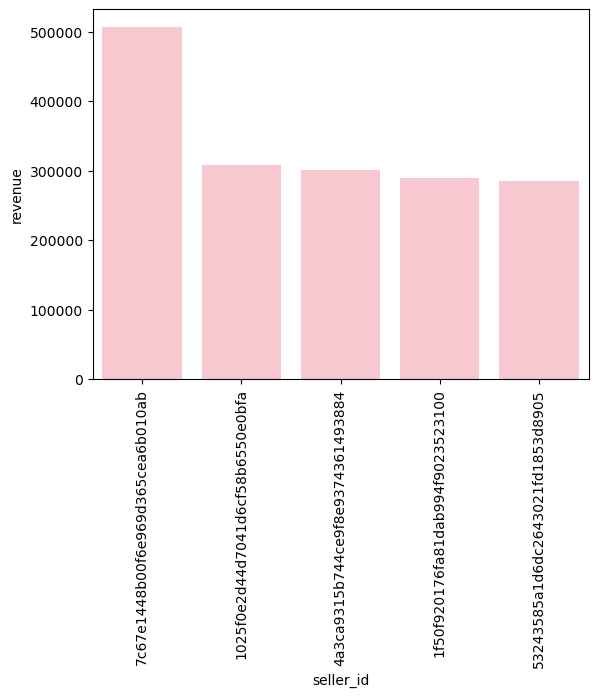

In [127]:
query = """ select *, dense_rank() over(order by revenue desc) from (select order_items.seller_id, round(sum(payments.payment_value),2) revenue
from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["seller_id", "revenue", "Rank"])
df = df.head(5)
sns.barplot(x = "seller_id", y = "revenue", data = df,  color = "pink")
plt.xticks(rotation = 90)
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [133]:
query = """select customer_id, order_purchase_timestamp, payment, avg(payment) over(partition by customer_id order by order_purchase_timestamp rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp, payments.payment_value as payment
from payments join orders 
on payments.order_id = orders.order_id) as a
"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["customer_id", "order_purchase_timestamp", "payment", "mov_avg"])
df

,customer_id,order_purchase_timestamp,payment,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# Calculate the cumulative sales per month for each year.

In [141]:
query = """ select years, month, payment, sum(payment) over(order by years, month) cumulative_sales
from
(select year(orders.order_purchase_timestamp) as years, month(orders.order_purchase_timestamp) as month, sum(payments.payment_value) as payment
from orders join payments
on orders.order_id = payments.order_id
group by years, month  order by years, month) as a"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["year", "month", "sales", "cumulative_sales"])
df

,year,month,sales,cumulative_sales
0,2016,9,2.522400e+02,2.522400e+02
1,2016,10,5.909048e+04,5.934272e+04
2,2016,12,1.962000e+01,5.936234e+04
3,2017,1,1.384880e+05,1.978504e+05
4,2017,2,2.919080e+05,4.897584e+05
5,2017,3,4.498636e+05,9.396220e+05
6,2017,4,4.177880e+05,1.357410e+06
7,2017,5,5.929188e+05,1.950329e+06
8,2017,6,5.112764e+05,2.461605e+06
9,2017,7,5.923829e+05,3.053988e+06


 # Calculate the year-over-year growth rate of total sales.

In [148]:
query = """ with a as (select year(orders.order_purchase_timestamp) as years, round(sum(payments.payment_value),2) as payment
from orders join payments
on orders.order_id = payments.order_id
group by years order by years)

select years, (payment - lag(payment, 1) over(order by years))/
lag(payment, 1) over(order by years)*100 from a
"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["year", "YoY % growth"])
df

,year,YoY % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase

In [157]:
query = """with a as (select customers.customer_id, min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id), b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < date_add(first_order, interval 6 month)
group by a.customer_id)

select 100*(count(distinct a.customer_id)/count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id
"""
cursor.execute(query)
data = cursor.fetchall()
data

[(None,)]

# Identify the top 3 customers who spent the most money in each year

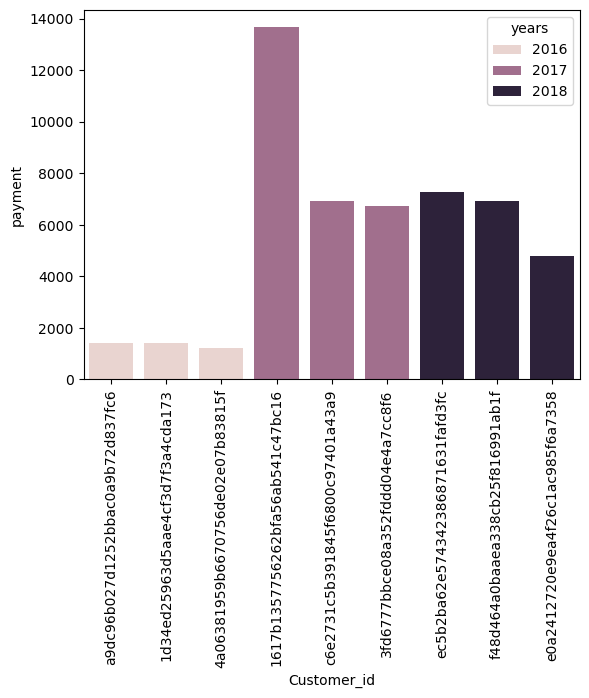

In [169]:
query = """select years, customer_id, payment, d_rank from (select year(orders.order_purchase_timestamp) years, orders.customer_id, sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp), orders.customer_id) as a
where d_rank <= 3 """
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["years", "Customer_id", "payment", "rank"])
sns.barplot(x = "Customer_id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()